In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [3]:
df=pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-12\weather_data.csv")

In [4]:
df

,date,meantempm,meantempm_1,meantempm_2,meantempm_3,meandewptm_1,meandewptm_2,meandewptm_3,meanpressurem_1,meanpressurem_2,...,mindewptm_3,maxpressurem_1,maxpressurem_2,maxpressurem_3,minpressurem_1,minpressurem_2,minpressurem_3,precipm_1,precipm_2,precipm_3
0,2015/1/4,-14,-4,-6,-6,-11,-9,-12,1016,1022,...,-18,1025,1026,1025,1010,1017,1019,0.76,0.00,0.00
1,2015/1/5,-9,-14,-4,-6,-19,-11,-9,1033,1016,...,-13,1043,1025,1026,1023,1010,1017,0.25,0.76,0.00
2,2015/1/6,-10,-9,-14,-4,-14,-19,-11,1032,1033,...,-16,1043,1043,1025,1023,1023,1010,0.00,0.25,0.76
3,2015/1/7,-16,-10,-9,-14,-15,-14,-19,1036,1032,...,-23,1043,1043,1043,1027,1023,1023,0.00,0.00,0.25
4,2015/1/8,-7,-16,-10,-9,-22,-15,-14,1035,1036,...,-17,1055,1043,1043,956,1027,1023,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,2017/9/23,28,30,25,22,20,18,13,1008,1008,...,10,1010,1011,1011,1007,1005,1000,0.00,0.00,0.00
993,2017/9/24,24,28,30,25,18,20,18,1011,1008,...,11,1013,1010,1011,1010,1007,1005,0.00,0.00,0.00
994,2017/9/25,16,24,28,30,18,18,20,1012,1011,...,17,1015,1013,1010,1010,1010,1007,14.99,0.00,0.00
995,2017/9/26,15,16,24,28,15,18,18,1014,1012,...,16,1015,1015,1013,1012,1010,1010,20.07,14.99,0.00


Using device: cpu
Epoch [10/200], Train Loss: 0.3499, Val Loss: 0.1504
Epoch [20/200], Train Loss: 0.1980, Val Loss: 0.1353
Epoch [30/200], Train Loss: 0.1849, Val Loss: 0.1256
Epoch [40/200], Train Loss: 0.1309, Val Loss: 0.1228
Early stopping at epoch 48

Model Performance Metrics:
MSE: 13.4375
RMSE: 3.6657
MAE: 2.8581
R2 Score: 0.9003


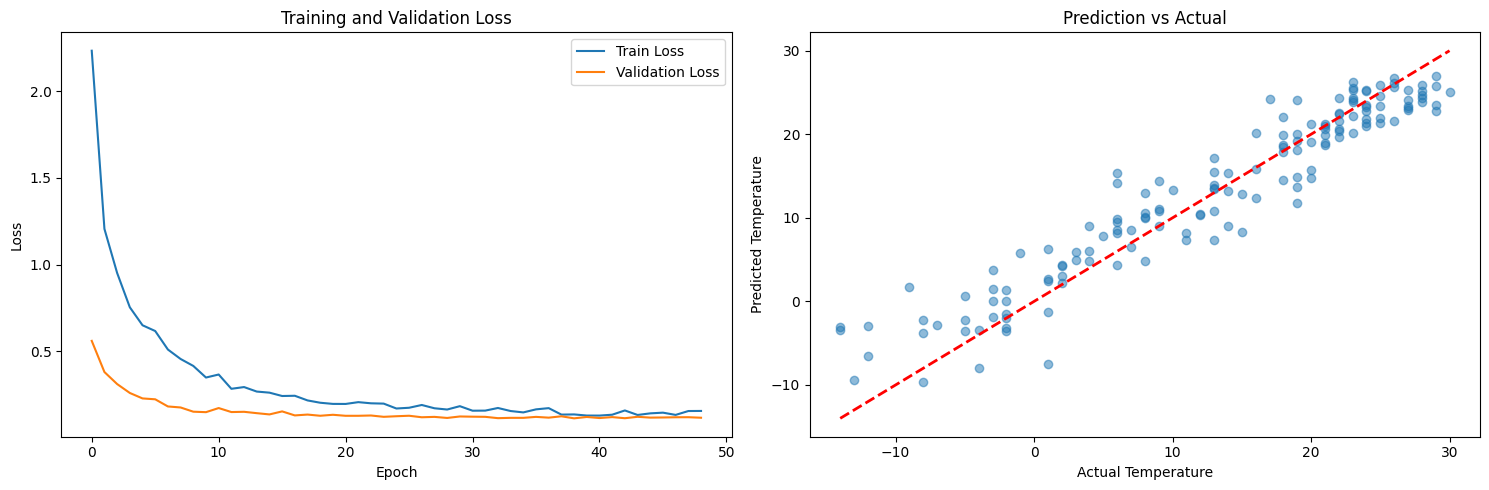

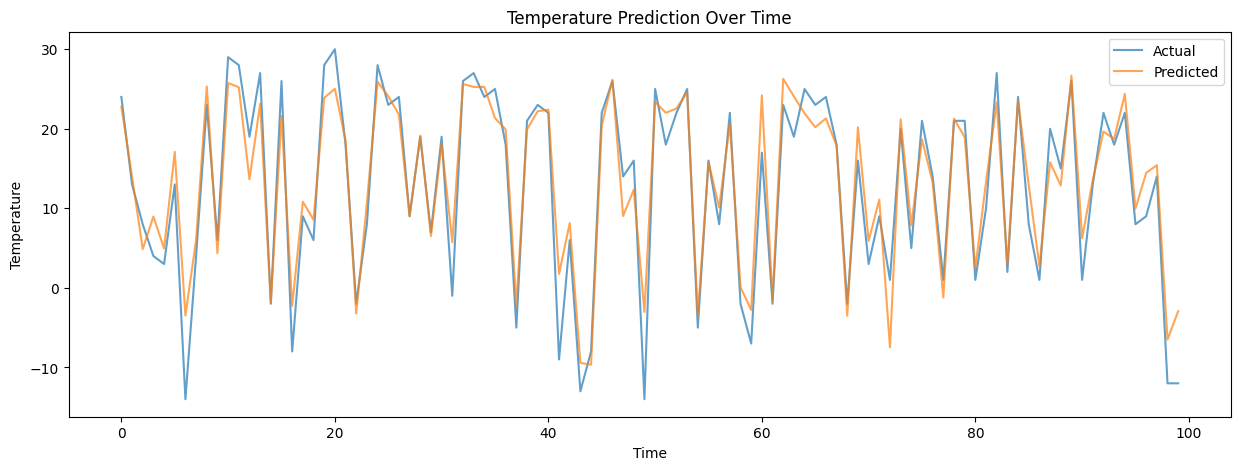

In [8]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子，确保结果可复现
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    
set_seed()

# 检查是否可以使用GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 数据预处理
def preprocess_data(df):
    # 去除异常值
    df = df[np.abs(df['meantempm'] - df['meantempm'].mean()) <= (3 * df['meantempm'].std())]
    
    # 特征工程
    X = df.drop(['meantempm', 'date'], axis=1)
    y = df['meantempm']
    
    # 标准化
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()
    
    return X_scaled, y_scaled, scaler_X, scaler_y

# 定义更复杂的模型架构
class WeatherModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32]):
        super(WeatherModel, self).__init__()
        layers = []
        
        # 输入层
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_dims[0]))
        layers.append(nn.Dropout(0.3))
        
        # 隐藏层
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_dims[i+1]))
            layers.append(nn.Dropout(0.2))
        
        # 输出层
        layers.append(nn.Linear(hidden_dims[-1], 1))
        
        self.model = nn.Sequential(*layers)
        
        # 初始化权重
        self.apply(self._init_weights)
    
    def _init_weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight)
            nn.init.constant_(layer.bias, 0)
    
    def forward(self, x):
        return self.model(x)

# 训练函数
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model = None
    patience = 10
    counter = 0
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            
            # 梯度裁剪，防止梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # 验证阶段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs.squeeze(), batch_y)
                val_loss += loss.item()
        
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # 学习率调整
        scheduler.step(val_loss)
        
        # 早停
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict().copy()
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
            
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    model.load_state_dict(best_model)
    return model, train_losses, val_losses

# 评估函数
def evaluate_model(model, X_test, y_test, scaler_y, device):
    model.eval()
    with torch.no_grad():
        X_test = torch.FloatTensor(X_test).to(device)
        y_pred = model(X_test).cpu().numpy()
        
        # 反标准化
        y_pred = scaler_y.inverse_transform(y_pred)
        y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1))
        
        # 计算各种指标
        mse = mean_squared_error(y_test_orig, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_orig, y_pred)
        r2 = r2_score(y_test_orig, y_pred)
        
        print("\nModel Performance Metrics:")
        print(f"MSE: {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R2 Score: {r2:.4f}")
        
        return y_pred, y_test_orig

# 可视化函数
def plot_results(train_losses, val_losses, y_pred, y_test):
    # 绘制损失曲线
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # 绘制预测vs实际值
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Temperature')
    plt.ylabel('Predicted Temperature')
    plt.title('Prediction vs Actual')
    
    plt.tight_layout()
    plt.show()
    
    # 绘制预测结果时间序列
    plt.figure(figsize=(15, 5))
    plt.plot(y_test[:100], label='Actual', alpha=0.7)
    plt.plot(y_pred[:100], label='Predicted', alpha=0.7)
    plt.title('Temperature Prediction Over Time')
    plt.xlabel('Time')
    plt.ylabel('Temperature')
    plt.legend()
    plt.show()

# 主函数
def main():
    # 预处理数据
    X_scaled, y_scaled, scaler_X, scaler_y = preprocess_data(df)
    
    # 划分数据集
    X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    # 创建数据加载器
    batch_size = 32
    train_dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)
    
    # 初始化模型
    input_dim = X_train.shape[1]
    model = WeatherModel(input_dim).to(device)
    
    # 定义损失函数和优化器
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    
    # 训练模型
    model, train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        epochs=200, device=device
    )
    
    # 评估模型
    y_pred, y_test_orig = evaluate_model(model, X_test, y_test, scaler_y, device)
    
    # 可视化结果
    plot_results(train_losses, val_losses, y_pred, y_test_orig)

if __name__ == "__main__":
    main()